In [3]:
from typing import TypedDict ,List ,Dict ,Any, Optional ,Literal
from pydantic import BaseModel ,Field,ConfigDict

In [4]:

EQUIPMENT_TAG_PATTERN = r"^[A-Z0-9]+-[A-Z]+-[0-9]{2}[A-Z]?$"

class Equipment(BaseModel):
    model_config=ConfigDict(extra="forbid")

    id :str =Field(description="Unique identifier of this equipment.")
    tag :str =Field(
        ...,
        pattern=EQUIPMENT_TAG_PATTERN,
        description=(
            "Equipment tag. Must match exactly: "
            "[A-Z0-9]+-[A-Z]+-[0-9]{2}[A-Z]?"
        )
    )
    area:str=Field(...,description="Area identifier. It is the first part of the equipment tag.",pattern=r"^[A-Z0-9]+$")
    equipment_type:str=Field(...,description="Equipment type code. It is the second part of the equipment tag.",pattern=r"^[A-Z]+$")
    equipment_name:str=Field(...,description="Human-readable name of the equipment.")
    sequence:str=Field(...,description="Equipment sequence number. It is the third part of the tag.",pattern=r"^[0-9]{2}[A-Z]?$")

In [5]:
class Pipeline(BaseModel):
    model_config=ConfigDict(extra="forbid")
    id: str
    from_equipment: Equipment=Field(...,description="Equipment at the start of the pipeline.")
    to_equipment: Equipment=Field(...,description="Equipment at the end of the pipeline.")

In [6]:
class PipelineChunk(BaseModel):
    id: str
    from_equipment: Equipment=Field(...,description="Equipment at the start of the pipeline.")
    to_equipment: Equipment=Field(...,description="Equipment at the end of the pipeline.")
    exit_edge: Optional[Literal["top", "bottom", "left", "right"]] = Field(
        default=None,
        description="Edge through which this pipeline visibly continues beyond this chunk, if any."
    )

In [7]:
class Instrument(BaseModel):
    model_config=ConfigDict(extra="forbid")
    id:str
    tag:str=Field(description="Instrument tag")
    attached_to:Equipment | Pipeline =Field(description="The equipment or pipeline to which the instrument is attached.")

In [8]:
def get_adjacent_chunk_ids(meta: ChunkMetadata, all_meta: list[ChunkMetadata]) -> dict[str, Optional[str]]:
    neighbors = {}
    directions = {"top": (-1, 0), "bottom": (1, 0), "left": (0, -1), "right": (0, 1)}
    for direction, (dr, dc) in directions.items():
        target_row, target_col = meta.row + dr, meta.col + dc
        match = next(
            (m for m in all_meta if m.row == target_row and m.col == target_col),
            None
        )
        neighbors[direction] = match.chunk_id if match else None
    return neighbors

In [9]:
class ChunkResult(BaseModel):
    model_config = ConfigDict(extra="forbid")

    metadata: ChunkMetadata
    equipment: List[Equipment]        
    instruments: List[Instrument]     
    pipelines: List[PipelineChunk]    


class PIDState(TypedDict):
    pdf_path: str
    coarse_equipment: List[Equipment]
    coarse_pipelines: List[Pipeline]      
    chunk_results: List[ChunkResult]      
    validated_data: Optional[Dict[str, Any]]  
    errors: List[str]

In [10]:
from dataclasses import dataclass

In [11]:
@dataclass(frozen=True)
class GridConfig:
    n_rows: int = 2
    n_cols: int = 1
    overlap_px: int = 128
    dpi: int = 200
    min_acceptable_patch_px: int = 800
    max_acceptable_patch_px: int = 4200

In [12]:
class Chunk(BaseModel):
    metadata: ChunkMetadata
    image_path: str

In [13]:
from pathlib import Path

In [14]:
from pdf2image import convert_from_path
from PIL import Image
def render_pdf_to_image(pdf_path: str, dpi: int = 200) -> Image.Image:
    pages = convert_from_path(pdf_path, dpi=dpi)
    if len(pages) != 1:
        raise ValueError(f"Expected a single-page PDF, got {len(pages)} pages: {pdf_path}")
    return pages[0]


In [15]:
class RawChunk(BaseModel):
    """Résultat intermédiaire, image encore en mémoire — jamais mis dans le State."""
    model_config = ConfigDict(arbitrary_types_allowed=True)
    metadata: ChunkMetadata
    image: Image.Image

In [16]:
def chunk_image(image: Image.Image, config: GridConfig) -> tuple[list[RawChunk], list[str]]:
    page_w_px, page_h_px = image.size
    core_w_px = page_w_px / config.n_cols
    core_h_px = page_h_px / config.n_rows

    errors = []
    if not (config.min_acceptable_patch_px <= core_w_px <= config.max_acceptable_patch_px):
        errors.append(f"Chunk width {core_w_px:.0f}px outside acceptable range")
    if not (config.min_acceptable_patch_px <= core_h_px <= config.max_acceptable_patch_px):
        errors.append(f"Chunk height {core_h_px:.0f}px outside acceptable range")

    raw_chunks: list[RawChunk] = []
    for row in range(config.n_rows):
        for col in range(config.n_cols):
            core_x0, core_y0 = col * core_w_px, row * core_h_px
            core_x1 = min(page_w_px, (col + 1) * core_w_px)
            core_y1 = min(page_h_px, (row + 1) * core_h_px)

            x0 = max(0.0, core_x0 - config.overlap_px)
            y0 = max(0.0, core_y0 - config.overlap_px)
            x1 = min(page_w_px, core_x1 + config.overlap_px)
            y1 = min(page_h_px, core_y1 + config.overlap_px)

            crop = image.crop((int(x0), int(y0), int(x1), int(y1)))

            metadata = ChunkMetadata(
                chunk_id=f"r{row}_c{col}",
                row=row, col=col,
                n_rows=config.n_rows, n_cols=config.n_cols,
                bbox_px=(x0, y0, x1, y1),
                core_bbox_px=(core_x0, core_y0, core_x1, core_y1),
            )
            raw_chunks.append(RawChunk(metadata=metadata, image=crop))

    return raw_chunks, errors

In [17]:
def deterministic_chunking(state: PIDState, config: GridConfig = GridConfig()) -> dict:
    image = render_pdf_to_image(state["pdf_path"], dpi=config.dpi)
    chunks, chunk_errors = chunk_image(image, config)  

    out_dir = Path("chunks") / Path(state["pdf_path"]).stem
    out_dir.mkdir(parents=True, exist_ok=True)

    saved_chunks = []
    for chunk in chunks:
        image_path = str(out_dir / f"{chunk.metadata.chunk_id}.png")
        chunk.image.save(image_path)
        saved_chunks.append(
            Chunk(metadata=chunk.metadata, image_path=image_path)
        )

    return {
        "chunks": saved_chunks,
        "errors": state.get("errors", []) + chunk_errors,
    }

In [18]:
import base64
import io 

MAX_ATTEMPTS=3

def encode_image(path:str)->str:
    with open(path,"rb")as f :
        return base64.b64encode(f.read()).decode("utf-8")


def build_chunk_prompt() -> str:
    return (
        "You are extracting equipment, instruments, and pipelines from a "
        "single cropped patch of a P&ID diagram. Only report what is visibly "
        "present in THIS image. Do not infer or guess content outside the "
        "visible boundaries. If a pipeline visibly continues past an edge "
        "of the image without reaching its destination inside this image, "
        "set exit_edge accordingly and leave the corresponding endpoint tag null."
    )

In [19]:
class ChunkExtraction(BaseModel):
    """Ce que le LLM local doit produire pour un chunk donné."""
    model_config = ConfigDict(extra="forbid")

    equipment: List[Equipment]
    instruments: List[Instrument]
    pipelines: List[PipelineChunk]

In [20]:
import json
from json import JSONDecodeError
from pydantic import ValidationError

In [21]:
import ollama

def call_local_llm_structured(
    prompt: str,
    image_b64: str,
    schema: type[BaseModel],
    model: str = "qwen3-vl:8b",
) -> BaseModel:
    response = ollama.chat(
        model=model,
        messages=[
            {
                "role": "user",
                "content": prompt,
                "images": [image_b64],
            }
        ],
        format=schema.model_json_schema(),
        options={"temperature": 0.0},
    )

    raw_content = response["message"]["content"]

    try:
        data = json.loads(raw_content)
    except JSONDecodeError as e:
        raise JSONDecodeError(f"Ollama returned invalid JSON: {e.msg}", e.doc, e.pos) from e

    return schema.model_validate(data)

In [22]:
MAX_ATTEMPTS = 3

def extract_chunk(state: dict) -> dict:
    chunk: Chunk = state["chunk"]
    attempt: int = state["attempt"]

    image_b64 = encode_image(chunk.image_path)
    prompt = build_chunk_prompt()

    try:
        result = call_local_llm_structured(
            prompt=prompt,
            image_b64=image_b64,
            schema=ChunkExtraction,
        )
    except (ValidationError, JSONDecodeError) as e:
        if attempt + 1 >= MAX_ATTEMPTS:
            return {
                "chunk_results": [],
                "errors": [f"Chunk {chunk.metadata.chunk_id} failed after {MAX_ATTEMPTS} attempts: {e}"],
                "needs_review": [chunk.metadata.chunk_id],
            }
        return extract_chunk({"chunk": chunk, "attempt": attempt + 1})

    chunk_result = ChunkResult(
        metadata=chunk.metadata,
        equipment=result.equipment,
        instruments=result.instruments,
        pipelines=result.pipelines,
    )
    return {"chunk_results": [chunk_result]}

In [23]:
def bbox_to_absolute(bbox_in_chunk: tuple[float, float, float, float], meta: ChunkMetadata, chunk_img_size: tuple[int, int]) -> tuple[float, float, float, float]:
    bx0, by0, bx1, by1 = bbox_in_chunk
    cw, ch = chunk_img_size
    px0, py0, px1, py1 = meta.bbox_px
    scale_x = (px1 - px0) / cw
    scale_y = (py1 - py0) / ch
    return (px0 + bx0 * scale_x, py0 + by0 * scale_y, px0 + bx1 * scale_x, py0 + by1 * scale_y)

def iou(a: tuple[float, float, float, float], b: tuple[float, float, float, float]) -> float:
    ax0, ay0, ax1, ay1 = a
    bx0, by0, bx1, by1 = b
    ix0, iy0 = max(ax0, bx0), max(ay0, by0)
    ix1, iy1 = min(ax1, bx1), min(ay1, by1)
    if ix1 <= ix0 or iy1 <= iy0:
        return 0.0
    inter = (ix1 - ix0) * (iy1 - iy0)
    area_a = (ax1 - ax0) * (ay1 - ay0)
    area_b = (bx1 - bx0) * (by1 - by0)
    return inter / (area_a + area_b - inter)

def deduplicate_instruments(chunk_results: list[ChunkResult], iou_threshold: float = 0.3) -> list[Instrument]:
    scored = []
    for cr in chunk_results:
        img = Image.open(cr.metadata.image_path)
        for inst in cr.instruments:
            abs_bbox = bbox_to_absolute(inst.bbox_in_chunk, cr.metadata, img.size)
            scored.append((inst, abs_bbox))

    kept: list[Instrument] = []
    kept_bboxes: list[tuple[float, float, float, float]] = []
    for inst, abs_bbox in scored:
        duplicate_idx = next(
            (i for i, kb in enumerate(kept_bboxes) if iou(kb, abs_bbox) >= iou_threshold),
            None,
        )
        if duplicate_idx is None:
            kept.append(inst)
            kept_bboxes.append(abs_bbox)
        # sinon : doublon d'overlap, on garde la première occurrence, on ignore la seconde
    return kept

In [24]:
def get_neighbor_chunk_id(meta: ChunkMetadata, edge: str) -> Optional[tuple[int, int]]:
    dr, dc = {"top": (-1, 0), "bottom": (1, 0), "left": (0, -1), "right": (0, 1)}[edge]
    target = (meta.row + dr, meta.col + dc)
    if 0 <= target[0] < meta.n_rows and 0 <= target[1] < meta.n_cols:
        return target
    return None  # bord absolu de la page

OPPOSITE_EDGE = {"top": "bottom", "bottom": "top", "left": "right", "right": "left"}

def stitch_pipelines(chunk_results: list[ChunkResult]) -> tuple[list[Pipeline], list[PipelineChunk]]:
    by_position = {(cr.metadata.row, cr.metadata.col): cr for cr in chunk_results}
    resolved: list[Pipeline] = []
    ambiguous: list[PipelineChunk] = []
    consumed: set[int] = set()

    fragments = [(cr, p) for cr in chunk_results for p in cr.pipelines]

    for i, (cr, frag) in enumerate(fragments):
        if i in consumed:
            continue

        # cas simple : les deux extrémités déjà résolues dans ce seul chunk
        if frag.from_equipment_tag and frag.to_equipment_tag:
            resolved.append(Pipeline(
                id=str(uuid.uuid4()), tag=frag.tag,
                from_equipment_tag=frag.from_equipment_tag,
                to_equipment_tag=frag.to_equipment_tag,
                source_chunk_ids=[cr.metadata.chunk_id],
            ))
            continue

        # cas à recoller : cherche le fragment jumeau dans le chunk voisin
        missing_end = "to" if frag.exit_edge and not frag.to_equipment_tag else "from"
        if not frag.exit_edge:
            ambiguous.append(frag)  # ni résolu ni exit_edge -> vraiment illisible, à envoyer au LLM cloud
            continue

        neighbor_pos = get_neighbor_chunk_id(cr.metadata, frag.exit_edge)
        if neighbor_pos is None:
            # bord absolu de page : la ligne s'arrête réellement là, rien à recoller
            resolved.append(Pipeline(
                id=str(uuid.uuid4()), tag=frag.tag,
                from_equipment_tag=frag.from_equipment_tag or "UNKNOWN",
                to_equipment_tag=frag.to_equipment_tag or "UNKNOWN",
                source_chunk_ids=[cr.metadata.chunk_id],
            ))
            continue

        neighbor_cr = by_position.get(neighbor_pos)
        twin_idx = next(
            (j for j, (ncr, nf) in enumerate(fragments)
             if ncr is neighbor_cr and nf.tag == frag.tag
             and nf.exit_edge == OPPOSITE_EDGE[frag.exit_edge]),
            None,
        )

        if twin_idx is not None:
            _, twin = fragments[twin_idx]
            resolved.append(Pipeline(
                id=str(uuid.uuid4()), tag=frag.tag,
                from_equipment_tag=frag.from_equipment_tag or twin.from_equipment_tag,
                to_equipment_tag=frag.to_equipment_tag or twin.to_equipment_tag,
                source_chunk_ids=[cr.metadata.chunk_id, neighbor_cr.metadata.chunk_id],
            ))
            consumed.add(twin_idx)
        else:
            ambiguous.append(frag)  # exit_edge annoncé mais aucun jumeau trouvé -> à trancher par le LLM

    return resolved, ambiguous

In [25]:
def needs_coarse_reconciliation(
    detailed_equipment: list[Equipment],
    coarse_equipment: list[Equipment],
) -> tuple[bool, list[str], list[str]]:
    detailed_tags = {e.tag for e in detailed_equipment}
    coarse_tags = {e.tag for e in coarse_equipment}

    missing_from_detail = coarse_tags - detailed_tags   # vu globalement, raté par le détail local
    missing_from_coarse = detailed_tags - coarse_tags   # vu localement, raté par la passe globale

    has_discrepancy = bool(missing_from_detail or missing_from_coarse)
    return has_discrepancy, sorted(missing_from_detail), sorted(missing_from_coarse)

In [26]:
class PipelineCorrection(BaseModel):
    model_config = ConfigDict(extra="forbid")
    tag: str = Field(description="Tag of the ambiguous pipeline fragment being resolved.")
    from_equipment_tag: str
    to_equipment_tag: str
    source_chunk_ids: List[str] = Field(description="Chunk IDs this resolution is based on.")

class InstrumentCorrection(BaseModel):
    model_config = ConfigDict(extra="forbid")
    kept_tag: str = Field(description="The tag to keep for this instrument.")
    discarded_tags: List[str] = Field(description="Other tag readings for the same physical instrument, judged to be OCR variants.")
    attached_to_tag: str
    attached_to_type: Literal["equipment", "pipeline"]

class MissingEquipmentResolution(BaseModel):
    model_config = ConfigDict(extra="forbid")
    tag: str
    resolution: Literal["confirmed_present", "false_positive"] = Field(
        description="confirmed_present: this equipment genuinely exists and detail extraction missed it. "
                    "false_positive: the coarse pass misread this and it does not actually exist."
    )

class ValidationOutput(BaseModel):
    model_config = ConfigDict(extra="forbid")
    resolved_pipelines: List[PipelineCorrection]
    resolved_instrument_duplicates: List[InstrumentCorrection]
    missing_equipment_resolutions: List[MissingEquipmentResolution]

In [27]:
def build_validation_prompt(
    state: PIDState,
    ambiguous_pipelines: list[PipelineChunk],
    missing_from_detail: list[str],
    missing_from_coarse: list[str],
) -> str:
    coarse_by_tag = {e.tag: e for e in state["coarse_equipment"]}

    sections = []

    if ambiguous_pipelines:
        frag_lines = "\n".join(
            f"- tag={f.tag}, from={f.from_equipment_tag}, to={f.to_equipment_tag}, exit_edge={f.exit_edge}"
            for f in ambiguous_pipelines
        )
        sections.append(
            "The following pipeline fragments could not be automatically reconciled "
            f"across chunks. Resolve each into a complete pipeline:\n{frag_lines}"
        )

    if missing_from_detail:
        sections.append(
            "The following equipment tags were seen in a global overview pass but "
            "not found in any detailed chunk extraction. For each, judge whether it "
            f"genuinely exists (missed by chunk extraction) or was a misread: {missing_from_detail}"
        )

    if missing_from_coarse:
        sections.append(
            "The following equipment tags were found in detailed chunk extraction "
            "but not seen in the global overview pass — for context only, no action needed: "
            f"{missing_from_coarse}"
        )

    return (
        "You are validating and correcting extracted P&ID data by reconciling "
        "a coarse whole-page pass with detailed per-patch extractions.\n\n"
        + "\n\n".join(sections)
    )

In [ ]:
from openai import OpenAI
from azure.identity import DefaultAzureCredential, get_bearer_token_provider

endpoint = ""
deployment_name = "gpt-5.6"

token_provider = get_bearer_token_provider(
    DefaultAzureCredential(),
    "https://ai.azure.com/.default"
)

client = OpenAI(
    base_url=endpoint,
    api_key=token_provider
)
def call_cloud_llm_structured(
    prompt: str,
    schema: type[BaseModel]
) -> BaseModel:

    response = client.responses.parse(
        model=deployment_name,
        input=prompt,
        text_format=schema,
    )

    return response.output_parsed

In [29]:
def merge_correction(
    all_equipment: list[Equipment],
    deduped_instruments: list[Instrument],
    resolved_pipelines: list[Pipeline],
    ambiguous_pipelines: list[PipelineChunk],
    coarse_equipment: list[Equipment],
    correction: ValidationOutput,
) -> dict:
    coarse_by_tag = {e.tag: e for e in coarse_equipment}

    final_equipment = list(all_equipment)
    for res in correction.missing_equipment_resolutions:
        if res.resolution == "confirmed_present":
            final_equipment.append(coarse_by_tag[res.tag])

    final_pipelines = list(resolved_pipelines)
    for corr in correction.resolved_pipelines:
        final_pipelines.append(Pipeline(
            id=str(uuid.uuid4()),
            tag=corr.tag,
            from_equipment_tag=corr.from_equipment_tag,
            to_equipment_tag=corr.to_equipment_tag,
            source_chunk_ids=corr.source_chunk_ids,
        ))

    discarded = {t for c in correction.resolved_instrument_duplicates for t in c.discarded_tags}
    final_instruments = [i for i in deduped_instruments if i.tag not in discarded]
    for c in correction.resolved_instrument_duplicates:
        final_instruments.append(Instrument(
            tag=c.kept_tag,
            attached_to_tag=c.attached_to_tag,
            attached_to_type=c.attached_to_type,
            bbox_in_chunk=(0, 0, 0, 0),  # provenance perdue à cette étape — voir remarque
        ))

    return {
        "equipment": final_equipment,
        "instruments": final_instruments,
        "pipelines": final_pipelines,
    }

In [30]:
def cloud_validation(state: PIDState) -> dict:
    all_equipment = [e for cr in state["chunk_results"] for e in cr.equipment]
    deduped_instruments = deduplicate_instruments(state["chunk_results"])
    resolved_pipelines, ambiguous_pipelines = stitch_pipelines(state["chunk_results"])

    if not ambiguous_pipelines and not needs_coarse_reconciliation(all_equipment, state["coarse_equipment"]):
        validated = {
            "equipment": all_equipment,
            "instruments": deduped_instruments,
            "pipelines": resolved_pipelines,
        }
        return {"validated_data": validated}

    correction = call_cloud_llm_structured(
        prompt=build_validation_prompt(state, ambiguous_pipelines),
        schema=ValidationOutput,  # à définir : delta uniquement, pas tout le dataset
    )
    validated = merge_correction(all_equipment, deduped_instruments, resolved_pipelines, correction)
    return {"validated_data": validated}

In [31]:
from typing import TypedDict, List, Annotated, Optional
import operator

class PIDState(TypedDict):
    pdf_path: str
    coarse_equipment: List[Equipment]
    coarse_pipelines: List[Pipeline]
    chunks: List[Chunk]
    chunk_results: Annotated[List[ChunkResult], operator.add]
    validated_data: Optional[dict]
    errors: Annotated[List[str], operator.add]
    needs_review: Annotated[List[str], operator.add]

In [32]:
class CoarseExtraction(BaseModel):
    model_config = ConfigDict(extra="forbid")
    equipment: List[Equipment]
    pipelines: List[Pipeline]

def cloud_coarse_extraction(state: PIDState) -> dict:
    image = render_pdf_to_image(state["pdf_path"], dpi=150)  # résolution basse, suffisante pour la topologie globale
    buf = io.BytesIO()
    image.save(buf, format="PNG")
    image_b64 = base64.b64encode(buf.getvalue()).decode("utf-8")

    prompt = (
        "Extract only equipment and the pipelines connecting them from this "
        "P&ID diagram. Do not report instruments. Assign each pipeline a tag "
        "and the equipment tags at each end."
    )
    result = call_cloud_llm_structured_vision(prompt, image_b64, CoarseExtraction)
    return {
        "coarse_equipment": result.equipment,
        "coarse_pipelines": result.pipelines,
    }

In [33]:
def cloud_validation(state: PIDState) -> dict:
    all_equipment = [e for cr in state["chunk_results"] for e in cr.equipment]
    deduped_instruments = deduplicate_instruments(state["chunk_results"])
    resolved_pipelines, ambiguous_pipelines = stitch_pipelines(state["chunk_results"])
    has_discrepancy, missing_from_detail, missing_from_coarse = needs_coarse_reconciliation(
        all_equipment, state["coarse_equipment"]
    )

    if not ambiguous_pipelines and not has_discrepancy:
        return {"validated_data": {
            "equipment": all_equipment,
            "instruments": deduped_instruments,
            "pipelines": resolved_pipelines,
        }}

    prompt = build_validation_prompt(state, ambiguous_pipelines, missing_from_detail, missing_from_coarse)
    correction = call_cloud_llm_structured(prompt, ValidationOutput)
    validated = merge_correction(
        all_equipment, deduped_instruments, resolved_pipelines,
        ambiguous_pipelines, state["coarse_equipment"], correction,
    )
    return {"validated_data": validated}

In [34]:
def persist_postgres(state: PIDState) -> dict:
    write_to_postgres(state["validated_data"])
    return {}

def persist_neo4j(state: PIDState) -> dict:
    write_to_neo4j(state["validated_data"])
    return {}

In [35]:
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

def dispatch_chunks(state: PIDState) -> list[Send]:
    return [
        Send("extract_chunk", {"chunk": chunk, "attempt": 0})
        for chunk in state["chunks"]
    ]

builder = StateGraph(PIDState)

builder.add_node("cloud_coarse_extraction", cloud_coarse_extraction)
builder.add_node("deterministic_chunking", deterministic_chunking)
builder.add_node("extract_chunk", extract_chunk)
builder.add_node("cloud_validation", cloud_validation)
builder.add_node("persist_postgres", persist_postgres)
builder.add_node("persist_neo4j", persist_neo4j)

builder.add_edge(START, "cloud_coarse_extraction")
builder.add_edge("cloud_coarse_extraction", "deterministic_chunking")
builder.add_conditional_edges("deterministic_chunking", dispatch_chunks, ["extract_chunk"])
builder.add_edge("extract_chunk", "cloud_validation")
builder.add_edge("cloud_validation", "persist_postgres")
builder.add_edge("cloud_validation", "persist_neo4j")
builder.add_edge("persist_postgres", END)
builder.add_edge("persist_neo4j", END)

graph = builder.compile()

/tmp/ipykernel_12488/3496293882.py:13: UserWarning: The 'config' parameter should be typed as 'RunnableConfig' or 'RunnableConfig | None', not '<class '__main__.GridConfig'>'. 
  builder.add_node("deterministic_chunking", deterministic_chunking)


In [36]:
# models.py
from typing import List, Literal, Optional
from pydantic import BaseModel, ConfigDict, Field

EQUIPMENT_TAG_PATTERN = r"^[A-Z0-9]+-[A-Z]+-[0-9]{2}[A-Z]?$"

class Equipment(BaseModel):
    model_config = ConfigDict(extra="forbid")
    tag: str = Field(..., pattern=EQUIPMENT_TAG_PATTERN)
    equipment_name: str

class PipelineChunk(BaseModel):
    model_config = ConfigDict(extra="forbid")
    tag: str
    from_equipment_tag: Optional[str] = None
    to_equipment_tag: Optional[str] = None
    exit_edge: Optional[Literal["top", "bottom", "left", "right"]] = None

class Pipeline(BaseModel):
    model_config = ConfigDict(extra="forbid")
    id: str
    tag: str
    from_equipment_tag: str
    to_equipment_tag: str
    source_chunk_ids: List[str]

class Instrument(BaseModel):
    model_config = ConfigDict(extra="forbid")
    tag: str
    attached_to_tag: str
    attached_to_type: Literal["equipment", "pipeline"]
    bbox_in_chunk: tuple[float, float, float, float]

class ChunkMetadata(BaseModel):
    model_config = ConfigDict(extra="forbid")
    chunk_id: str
    row: int
    col: int
    n_rows: int
    n_cols: int
    bbox_px: tuple[float, float, float, float]
    core_bbox_px: tuple[float, float, float, float]

class Chunk(BaseModel):
    model_config = ConfigDict(extra="forbid")
    metadata: ChunkMetadata
    image_path: str

class ChunkExtraction(BaseModel):
    model_config = ConfigDict(extra="forbid")
    equipment: List[Equipment]
    instruments: List[Instrument]
    pipelines: List[PipelineChunk]

class ChunkResult(BaseModel):
    model_config = ConfigDict(extra="forbid")
    metadata: ChunkMetadata
    equipment: List[Equipment]
    instruments: List[Instrument]
    pipelines: List[PipelineChunk]

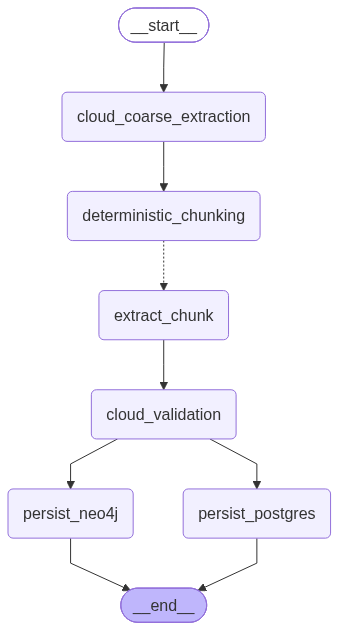

In [37]:
graph

In [38]:
import psycopg
import uuid

def write_to_postgres(validated_data: dict, document_id: str, dsn: str) -> None:
    with psycopg.connect(dsn) as conn:
        with conn.cursor() as cur:
            for eq in validated_data["equipment"]:
                cur.execute(
                    """INSERT INTO equipment (tag, equipment_name, area, equipment_type, sequence, document_id)
                       VALUES (%s, %s, %s, %s, %s, %s)
                       ON CONFLICT (tag) DO NOTHING""",
                    (eq.tag, eq.equipment_name, eq.area, eq.equipment_type, eq.sequence, document_id),
                )
            for pl in validated_data["pipelines"]:
                cur.execute(
                    """INSERT INTO pipeline (id, tag, from_equipment_tag, to_equipment_tag, source_chunk_ids, document_id)
                       VALUES (%s, %s, %s, %s, %s, %s)""",
                    (pl.id, pl.tag, pl.from_equipment_tag, pl.to_equipment_tag, pl.source_chunk_ids, document_id),
                )
            for inst in validated_data["instruments"]:
                cur.execute(
                    """INSERT INTO instrument (tag, attached_to_tag, attached_to_type, document_id)
                       VALUES (%s, %s, %s, %s)
                       ON CONFLICT (tag) DO NOTHING""",
                    (inst.tag, inst.attached_to_tag, inst.attached_to_type, document_id),
                )
        conn.commit()

In [39]:
from neo4j import GraphDatabase

def write_to_neo4j(validated_data: dict, document_id: str, uri: str, auth: tuple[str, str]) -> None:
    driver = GraphDatabase.driver(uri, auth=auth)
    with driver.session() as session:
        for eq in validated_data["equipment"]:
            session.run(
                """MERGE (e:Equipment {tag: $tag})
                   SET e.equipment_name = $name, e.area = $area,
                       e.equipment_type = $type, e.document_id = $doc_id""",
                tag=eq.tag, name=eq.equipment_name, area=eq.area,
                type=eq.equipment_type, doc_id=document_id,
            )

        for pl in validated_data["pipelines"]:
            session.run(
                """MATCH (from:Equipment {tag: $from_tag}), (to:Equipment {tag: $to_tag})
                   MERGE (from)-[r:CONNECTS_TO {tag: $pl_tag}]->(to)
                   SET r.id = $id, r.source_chunk_ids = $chunks, r.document_id = $doc_id""",
                from_tag=pl.from_equipment_tag, to_tag=pl.to_equipment_tag,
                pl_tag=pl.tag, id=pl.id, chunks=pl.source_chunk_ids, doc_id=document_id,
            )

        for inst in validated_data["instruments"]:
            session.run(
                """MERGE (i:Instrument {tag: $tag}) SET i.document_id = $doc_id
                   WITH i
                   MATCH (target {tag: $attached_tag})
                   MERGE (i)-[:ATTACHED_TO]->(target)""",
                tag=inst.tag, attached_tag=inst.attached_to_tag, doc_id=document_id,
            )
    driver.close()

In [40]:
class PersistResult(TypedDict):
    postgres_ok: bool
    neo4j_ok: bool

def persist_postgres(state: PIDState) -> dict:
    try:
        write_to_postgres(state["validated_data"], state["document_id"], PG_DSN)
        return {"postgres_ok": True}
    except Exception as e:
        return {"postgres_ok": False, "errors": [f"Postgres write failed: {e}"]}

def persist_neo4j(state: PIDState) -> dict:
    try:
        write_to_neo4j(state["validated_data"], state["document_id"], NEO4J_URI, NEO4J_AUTH)
        return {"neo4j_ok": True}
    except Exception as e:
        return {"neo4j_ok": False, "errors": [f"Neo4j write failed: {e}"]}

def verify_dual_write(state: PIDState) -> dict:
    pg_ok = state.get("postgres_ok", False)
    neo_ok = state.get("neo4j_ok", False)
    if pg_ok and neo_ok:
        return {}
    if pg_ok and not neo_ok:
        return {"needs_review": [f"{state['document_id']}: written to Postgres only, Neo4j failed"]}
    if neo_ok and not pg_ok:
        return {"needs_review": [f"{state['document_id']}: written to Neo4j only, Postgres failed"]}
    return {"needs_review": [f"{state['document_id']}: failed both persistence targets"]}

In [41]:
builder.add_node("verify_dual_write", verify_dual_write)
builder.add_edge("persist_postgres", "verify_dual_write")
builder.add_edge("persist_neo4j", "verify_dual_write")
builder.add_edge("verify_dual_write", END)

Adding a node to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.


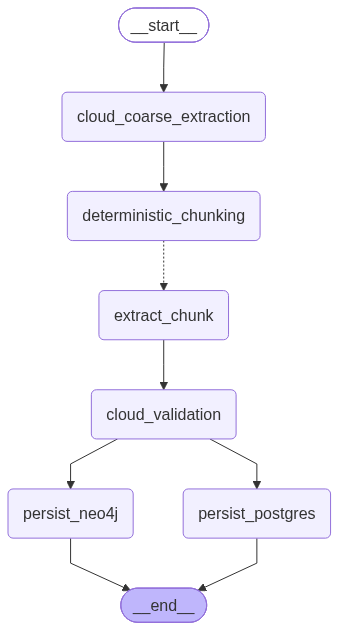

In [42]:
graph


In [43]:
import hashlib
from pathlib import Path

def make_document_id(pdf_path: str) -> str:
    with open(pdf_path, "rb") as f:
        content_hash = hashlib.sha256(f.read()).hexdigest()[:16]
    return f"{Path(pdf_path).stem}_{content_hash}"

In [44]:
import io
import base64


In [45]:
from pydantic import BaseModel


def call_cloud_llm_structured_vision(
    prompt: str,
    image_b64: str,
    schema: type[BaseModel],
) -> BaseModel:

    response = client.responses.parse(
        model=deployment_name,
        input=[
            {
                "role": "user",
                "content": [
                    {
                        "type": "input_text",
                        "text": prompt,
                    },
                    {
                        "type": "input_image",
                        "image_url": f"data:image/png;base64,{image_b64}",
                    },
                ],
            }
        ],
        text_format=schema,
    )

    return response.output_parsed

In [46]:
result = graph.invoke({
    "pdf_path": str(Path("~/Downloads/pid1.pdf").expanduser()),
    "document_id": make_document_id(str(Path("~/Downloads/pid1.pdf").expanduser())),
    "chunk_results": [],
    "errors": [],
    "needs_review": [],
})

TypeError: write_to_neo4j() missing 3 required positional arguments: 'document_id', 'uri', and 'auth'